# NMF with TIDF and Evaluation Metrics
* TF-IDF for vectorization (downweigh overly common words)
* NMF for topic modeling
* Evaluate model quality across different k using coherence, diversity and reconstruction error <br>
--> Plot metrics
* Visualize topic space using PCA & UMAP <br>
--> Present topic clusters and top words for optimal k

In [1]:
import pandas as pd
import numpy as np

from sklearn.feature_extraction.text import TfidfVectorizer
from gensim.corpora import Dictionary
from sklearn.decomposition import NMF, PCA
from gensim.models import CoherenceModel
from sklearn.preprocessing import MinMaxScaler

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import umap
from matplotlib.lines import Line2D

In [2]:
# Load preprocessed data
df = pd.read_pickle("data/preprocessed_data.pkl")
df.head(5)

,id,author,question,link_flair_css_class,link_flair_text,description,created_utc,year,retrieved_on,org_post,language,clean_question,clean_desc,question_tokens,desc_tokens,q_tuple,d_tuple,post_tokens,clean_text
0,421zyl,[deleted],How is time defined at the big bang?,physics,Physics,[removed],2016-01-21 20:58:09,2016,2016-02-09 12:21:05,How is time defined at the big bang? [removed],en,how is time defined at the big bang,removed,"[time, define, big, bang]",[],"(time, define, big, bang)",(),"[time, define, big_bang]",time define big_bang
1,4r857d,[deleted],UFO best scientific explanation. Atmospherical...,geo,Earth Sciences,[removed],2016-07-04 17:05:51,2016,2016-09-03 18:04:14,UFO best scientific explanation. Atmospherical...,en,ufo best scientific explanation atmospherical ...,removed,"[ufo, good, scientific, explanation, atmospher...",[],"(ufo, good, scientific, explanation, atmospher...",(),"[ufo, good, scientific_explanation, atmospheri...",ufo good scientific_explanation atmospherical ...
2,4r0zwj,De_La_Soul_,It's a commonly known fact that metals oxidize...,chem,Chemistry,,2016-07-03 06:40:06,2016,2016-09-02 17:31:58,It's a commonly known fact that metals oxidize...,en,it s a commonly known fact that metals oxidize...,,"[s, commonly, know, fact, metal, oxidize, poss...",[],"(s, commonly, know, fact, metal, oxidize, poss...",(),"[s, commonly, know, fact, metal, oxidize, poss...",s commonly know fact metal oxidize possible di...
3,540ohz,MacShakeIt,"China builds large telescope, but i have a que...",astro,Astronomy,[removed],2016-09-22 19:17:55,2016,2016-10-14 11:02:04,"China builds large telescope, but i have a que...",en,china builds large telescope but i have a ques...,removed,"[china, build, large, telescope, question]",[],"(china, build, large, telescope, question)",(),"[china, build, large, telescope, question]",china build large telescope question
4,4r191k,[deleted],Geoscientists: Is there any current research i...,geo,Planetary Sci.,[removed],2016-07-03 08:26:38,2016,2016-09-02 17:34:09,Geoscientists: Is there any current research i...,en,geoscientists is there any current research in...,removed,"[geoscientist, current, research, project, sho...",[],"(geoscientist, current, research, project, sho...",(),"[geoscientist, current, research_project, shor...",geoscientist current research_project shortfal...


## TFIDF Vectorization

In [3]:
vectorizer = TfidfVectorizer(
    max_features=10000,
    ngram_range=(1, 1),
    min_df=5,            # ignore words in < 5 docs
    max_df=0.8           # ignore words in > 80% of docs
)
X = vectorizer.fit_transform(df['clean_text'])
feature_names = vectorizer.get_feature_names_out()

# Vocabulary size
print(len(vectorizer.vocabulary_))
# Feature names
print(feature_names)
# Sparse feature matrix
print(X)

10000
['00' '00_00' '00_year' ... 'zoology' 'zoom' 'zygote']
<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 3619007 stored elements and shape (591178, 10000)>
  Coords	Values
  (0, 9134)	0.38975418127933237
  (0, 2482)	0.6861664120449172
  (0, 1080)	0.6142209155968902
  (1, 9367)	0.5503332389657914
  (1, 4086)	0.30062202907411234
  (1, 7909)	0.46737197556934584
  (1, 3277)	0.3811243249822899
  (1, 5745)	0.49301866808872985
  (2, 1924)	0.4664460421950509
  (2, 5128)	0.24619228562412446
  (2, 3454)	0.3836851142824323
  (2, 5735)	0.3613525524970021
  (2, 6482)	0.5251513872321245
  (2, 6945)	0.22711939482781837
  (2, 3931)	0.34155572763890385
  (3, 1701)	0.5610085523196993
  (3, 1368)	0.42508145152853666
  (3, 5171)	0.37784760111484705
  (3, 8982)	0.49374017115323093
  (3, 7284)	0.3435505748967413
  (4, 2336)	0.314455135342072
  (4, 7619)	0.5137052202804001
  (4, 5092)	0.4211874428828948
  (4, 5820)	0.42256588615769203
  (4, 3069)	0.3277825986608701
  :	:
  (591173, 7284)	0.

### Define Helper Functions for Evaluation Metrics & Visualization

In [31]:
# Helper functions
def get_top_words(model, vectorizer, n_top=15):
    """Return top words for each topic as list of lists."""
    feature_names = vectorizer.get_feature_names_out()
    topics = []
    for comp in model.components_:
        top_idx = np.argsort(comp)[::-1][:n_top]
        topics.append([feature_names[i] for i in top_idx])
    return topics

def topic_diversity(topics, topk=10):
    """Compute topic diversity: fraction of unique words among top k words."""
    top_words = [word for topic in topics for word in topic[:topk]]
    return len(set(top_words)) / len(top_words)

In [9]:
def plot_nmf_metrics(
    results,
    k_min,
    k_max,
    step,
    coherence_weight=0.5,
    error_weight=0.3,
    diversity_weight=0.2,
    vertical_line_k=None
):

    # Extract values from results
    k_vals = [r[0] for r in results]
    coherence = np.array([r[1] for r in results]).reshape(-1, 1)
    errors = np.array([r[2] for r in results]).reshape(-1, 1)
    diversity = np.array([r[3] for r in results]).reshape(-1, 1)

    # Build summary table
    summary = pd.DataFrame({
        'k': k_vals,
        'Coherence': coherence.flatten(),
        'Diversity': diversity.flatten(),
        'Reconstruction_Error': errors.flatten()
    })

    # Normalize metrics
    scaler = MinMaxScaler()
    summary[['Coherence_norm', 'Diversity_norm', 'Error_norm']] = scaler.fit_transform(
        summary[['Coherence', 'Diversity', 'Reconstruction_Error']]
    )

    # Invert reconstruction error
    summary['Error_norm'] = 1 - summary['Error_norm']

    summary['Composite_Score'] = (
        coherence_weight * summary['Coherence_norm'] +
        diversity_weight * summary['Diversity_norm'] +
        error_weight * summary['Error_norm']
    )

    # Print table with scores
    print(summary[['k', 'Coherence', 'Diversity', 'Reconstruction_Error', 'Coherence_norm', 'Diversity_norm', 'Error_norm', 'Composite_Score']])

    # Plot
    plt.figure(figsize=(10, 6))

    # Plot metrics
    plt.plot(k_vals, summary['Coherence_norm'], marker='o', label='Coherence')
    plt.plot(k_vals, summary['Error_norm'], marker='s', label='Reconstruction Error')
    plt.plot(k_vals, summary['Diversity_norm'], marker='^', label='Topic Diversity')
    plt.plot(k_vals, summary['Composite_Score'], marker='^', color='black', alpha=0.5, label='Combined Score')

    # Add vertical line if specified
    if vertical_line_k is not None:
        plt.axvline(x=vertical_line_k, color='black', linestyle='--', alpha=0.5, label=f'k={vertical_line_k}')

    # Labels and title
    plt.xlabel("Number of Topics (k)")
    plt.ylabel("Normalized Score")
    plt.title("NMF Model Evaluation")

    # Legend and grid
    plt.legend()
    plt.grid(visible=True)
    # plt.grid(visible=True, which='major', axis='x', linestyle='-', linewidth=0.5)
    plt.gca().xaxis.set_major_locator(plt.MultipleLocator(5))

    # Hide spines
    for spine in ['top', 'right', 'bottom', 'left']:
        plt.gca().spines[spine].set_visible(False)

    plt.tight_layout()

    # Save with hardcoded path and dpi
    plt.savefig(f'viz/NMF_evaluation_metrics-{k_min}-{k_max}-{step}.png', dpi=300)

    plt.show()

### NMF Loop for different values of *k*

In [6]:
k_min = 2
k_max = 50
step = 1
k_values = range(k_min, k_max + 1, step)

results = []

dictionary = Dictionary(df['post_tokens'])

In [ ]:
# Main loop for different values of k
for k in k_values:
    print(f"Running NMF for k={k}")

    # Fit NMF model
    nmf = NMF(n_components=k, random_state=42, init='nndsvda', max_iter=1000)
    W = nmf.fit_transform(X)
    H = nmf.components_
    error = nmf.reconstruction_err_

    # Get top words per topic
    topics = get_top_words(nmf, vectorizer, n_top=15)

    # Topic labels for display
    topic_labels = {}
    for topic_idx, topic in enumerate(H):
        top_words = [feature_names[i] for i in topic.argsort()[:-4:-1]]
        topic_labels[topic_idx] = f"Topic {topic_idx}: {', '.join(top_words)}"

    # Compute coherence metric
    coherence_model = CoherenceModel(
        topics=topics,
        texts=df['post_tokens'],
        dictionary=dictionary,
        coherence='c_v'
    )
    coherence = coherence_model.get_coherence()
    diversity = topic_diversity(topics)

    results.append((k, coherence, error, diversity))


Running NMF for k=2
Running NMF for k=3
Running NMF for k=4
Running NMF for k=5
Running NMF for k=6
Running NMF for k=7
Running NMF for k=8
Running NMF for k=9
Running NMF for k=10
Running NMF for k=11
Running NMF for k=12
Running NMF for k=13
Running NMF for k=14
Running NMF for k=15
Running NMF for k=16
Running NMF for k=17
Running NMF for k=18
Running NMF for k=19
Running NMF for k=20
Running NMF for k=21
Running NMF for k=22
Running NMF for k=23
Running NMF for k=24
Running NMF for k=25
Running NMF for k=26
Running NMF for k=27
Running NMF for k=28
Running NMF for k=29
Running NMF for k=30
Running NMF for k=31
Running NMF for k=32
Running NMF for k=33
Running NMF for k=34
Running NMF for k=35
Running NMF for k=36
Running NMF for k=37
Running NMF for k=38
Running NMF for k=39
Running NMF for k=40
Running NMF for k=41
Running NMF for k=42
Running NMF for k=43
Running NMF for k=44
Running NMF for k=45
Running NMF for k=46
Running NMF for k=47
Running NMF for k=48
Running NMF for k=49


     k  Coherence  Diversity  Reconstruction_Error  Coherence_norm  \
0    2   0.518567   0.950000            762.982261        0.063491   
1    3   0.513231   0.866667            761.552660        0.000000   
2    4   0.563524   0.900000            760.236826        0.598448   
3    5   0.566030   0.820000            758.934185        0.628267   
4    6   0.574349   0.850000            757.744550        0.727251   
5    7   0.573810   0.814286            756.490618        0.720843   
6    8   0.557981   0.812500            755.443481        0.532488   
7    9   0.576750   0.788889            754.164512        0.755826   
8   10   0.594139   0.730000            753.028517        0.962738   
9   11   0.563451   0.763636            752.118600        0.597582   
10  12   0.561857   0.708333            750.997139        0.578610   
11  13   0.555481   0.684615            750.016385        0.502735   
12  14   0.561146   0.685714            749.038803        0.570150   
13  15   0.559487   

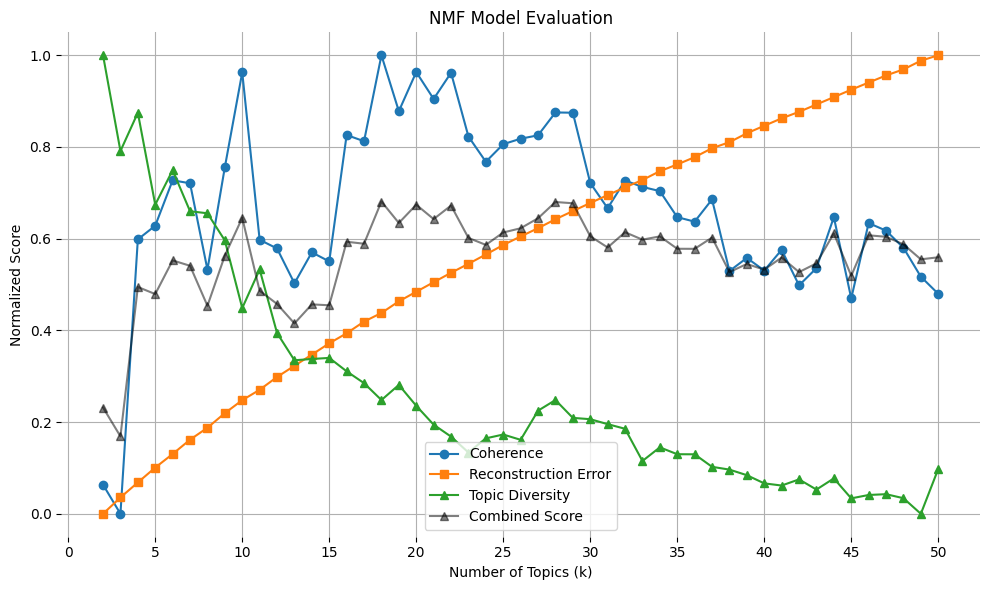

In [10]:
plot_nmf_metrics(results, k_min=k_min, k_max=k_max, step=step)

Best k = .

## NMF with Best Values for *k*

In [ ]:
# def get_topic_labels(model, vectorizer, n_words=5):

  #  words = vectorizer.get_feature_names_out()
  #  topic_labels = {}

    #for i, topic in enumerate(model.components_):

     #   top_words = [
      #      words[j]
       #     for j in topic.argsort()[-n_words:][::-1]
        #]

        #topic_labels[i] = " | ".join(top_words)

    #return topic_labels

In [26]:
def get_topic_labels(model, vectorizer, n_words=15):
    words = vectorizer.get_feature_names_out()
    topic_labels = {}

    for i, topic in enumerate(model.components_):
        top_words = [words[j] for j in topic.argsort()[-n_words:]]
        topic_labels[i] = top_words
    return topic_labels

### Projection into 2-D Space

In [27]:
def plot_2D_projection_nmf(nmf, X, k, df, vectorizer):

    W = nmf.fit_transform(X)

    # --- assign topics ---
    df["topic"] = W.argmax(axis=1)
    df["topic_prob"] = W.max(axis=1)

    # --- labels ---
    topic_labels = get_topic_labels(nmf, vectorizer)
    df["topic_label"] = df["topic"].map(topic_labels)

    # --- colors ---
    topic_ids = sorted(df["topic"].unique())
    cmap = plt.colormaps.get_cmap("tab20")
    colors = [cmap(i) for i in range(len(topic_ids))]
    color_map = {t: colors[i % len(colors)] for i, t in enumerate(topic_ids)}
    topic_colors = df["topic"].map(color_map)

    sns.set_theme(style='whitegrid', context='paper')
    spine_color = '#cccccc'

    # --- PCA ---
    pca = PCA(n_components=2, random_state=42)
    W_pca = pca.fit_transform(W)

    # --- UMAP ---
    reducer = umap.UMAP(
        n_components=2,
        n_neighbors=15,
        min_dist=0.1,
        n_jobs=-1
    )
    W_umap = reducer.fit_transform(W)

    # --- plot ---
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    titles = ["PCA Projection", "UMAP Projection"]

    for ax, emb, title in zip(axes, [W_pca, W_umap], titles):
        ax.scatter(
            emb[:, 0],
            emb[:, 1],
            c=topic_colors,
            s=6,
            alpha=0.6
        )

        ax.set_title(f"{title} of NMF Topic Space (k={k})", fontsize=15)
        ax.set_xlabel("Component 1")
        ax.set_ylabel("Component 2")
        ax.grid(alpha=0.3)

        for spine in ax.spines.values():
            spine.set_color(spine_color)

    legend_elements = [
        Line2D(
            [0], [0],
            marker='o', color='w',
            markerfacecolor=cmap(t % 20),
            markersize=8,
            label=f"Topic {t}"
        )
        for t in topic_ids
    ]

    axes[1].legend(
        handles=legend_elements,
        title="Topics",
        bbox_to_anchor=(1.05, 1),
        loc='upper left',
        frameon=False
    )

    plt.tight_layout()

    plt.savefig(f"viz/NMF_pca_vs_umap_k{k}.png", dpi=300)
    
    plt.show()

In [28]:
def plot_bars_topic_distribution(k):
    """
    Create a bar plot showing the distribution of documents across topics, with topic labels based on top words.
    """

    # Set default color if not provided
    color = plt.colormaps["tab20b"](0)

    # Create plot
    fig, ax = plt.subplots(figsize=(10, 6))

    sns.countplot(
        data=df,
        y="topic_label",
        order=df['topic_label'].value_counts().index,
        ax=ax,
        color=color
    )

    # Formatting
    ax.set_title(f"Publications by Topic (k={k})", fontsize=16)
    ax.set_xlabel("")
    ax.set_ylabel("")

    ax.tick_params(axis='y', labelsize=11)
    ax.tick_params(axis='x', labelsize=11)

    ax.xaxis.set_major_formatter(mticker.StrMethodFormatter('{x:,.0f}'))

    # Hide spines
    for spine in ['top', 'right', 'bottom']:
        ax.spines[spine].set_visible(False)

    ax.grid(axis="y", visible=False)

    plt.tight_layout()

    # Save or show
    plt.savefig(f"viz/NMF_posts_per_topic_k{k}.png", dpi=300)
    plt.show()

In [29]:
def plot_box_topic_confidence(k):
    """
    Plot boxplot of topic probabilities with top words as legend.
    """
    # Create plot
    fig, ax = plt.subplots(figsize=(10, 6))

    # Set default color if not provided
    color = plt.colormaps["tab20b"](5)

    # Boxplot
    sns.boxplot(
        data=df,
        x="topic",
        y="topic_prob",
        color=color,
        ax=ax
    )

    # Titles and labels
    ax.set_title("Topic Probability Distribution per Topic", fontsize=16)
    ax.set_xlabel("Topic", fontsize=12)
    ax.set_ylabel("Topic Confidence", fontsize=12)

    # Despine plot
    for spine in ['top', 'right', 'bottom']:
        ax.spines[spine].set_visible(False)

    fig.subplots_adjust(right=0.7)
    plt.tight_layout()
    plt.savefig(f"viz/NMF_topic_confidence_k{k}.png", dpi=300)
    plt.show()

In [32]:
k = 10
nmf = NMF(n_components=k, random_state=42, init='nndsvda', max_iter=1000)

W = nmf.fit_transform(X)

df["topic"] = W.argmax(axis=1)
df["topic_prob"] = W.max(axis=1)

topic_labels = get_topic_labels(nmf, vectorizer)
df["topic_label"] = df["topic"].map(topic_labels)

print(topic_labels)

get_top_words(nmf, vectorizer)

# plot_2D_projection_nmf(nmf, X, k, df, vectorizer)


{0: ['rotation', 'mar', 'star', 'surface', 'effect', 'space', 'atmosphere', 'affect', 'life', 'orbit', 'gravity', 'sun', 'planet', 'moon', 'earth'], 1: ['way', 'different', 'able', 'dog', 'like', 'live', 'survive', 'eye', 'long', 'brain', 'evolution', 'specie', 'evolve', 'animal', 'human'], 2: ['universe', 'big_bang', 'collide', 'suddenly', 'inside', 'get', 'space', 'go', 'person', 'die', 'exactly', 'actually', 'brain', 'black_hole', 'happen'], 3: ['change', 'speed_light', 'question', 'experience', 'stop', 'gravity', 'speed', 'fast', 'exist', 'slow', 'long', 'universe', 'travel', 'space', 'time'], 4: ['need', 'warm', 'fast', 'pressure', 'heat', 'liquid', 'ice', 'freeze', 'ocean', 'air', 'temperature', 'hot', 'cold', 'drink', 'water'], 5: ['doesn_t', 'well', 'help', 'magnet', 'stop', 'brain', 'vaccine', 'energy', 'way', 'explain', 'gravity', 'space', 'exactly', 'actually', 'work'], 6: ['small', 'person', 'build', 'way', 'actually', 'star', 'life', 'black_hole', 'energy', 'exist', 'use',

[['earth',
  'moon',
  'planet',
  'sun',
  'gravity',
  'orbit',
  'life',
  'affect',
  'atmosphere',
  'space',
  'effect',
  'surface',
  'star',
  'mar',
  'rotation'],
 ['human',
  'animal',
  'evolve',
  'specie',
  'evolution',
  'brain',
  'long',
  'eye',
  'survive',
  'live',
  'like',
  'dog',
  'able',
  'different',
  'way'],
 ['happen',
  'black_hole',
  'brain',
  'actually',
  'exactly',
  'die',
  'person',
  'go',
  'space',
  'get',
  'inside',
  'suddenly',
  'collide',
  'big_bang',
  'universe'],
 ['time',
  'space',
  'travel',
  'universe',
  'long',
  'slow',
  'exist',
  'fast',
  'speed',
  'gravity',
  'stop',
  'experience',
  'question',
  'speed_light',
  'change'],
 ['water',
  'drink',
  'cold',
  'hot',
  'temperature',
  'air',
  'ocean',
  'freeze',
  'ice',
  'liquid',
  'heat',
  'pressure',
  'fast',
  'warm',
  'need'],
 ['work',
  'actually',
  'exactly',
  'space',
  'gravity',
  'explain',
  'way',
  'energy',
  'vaccine',
  'brain',
  'stop

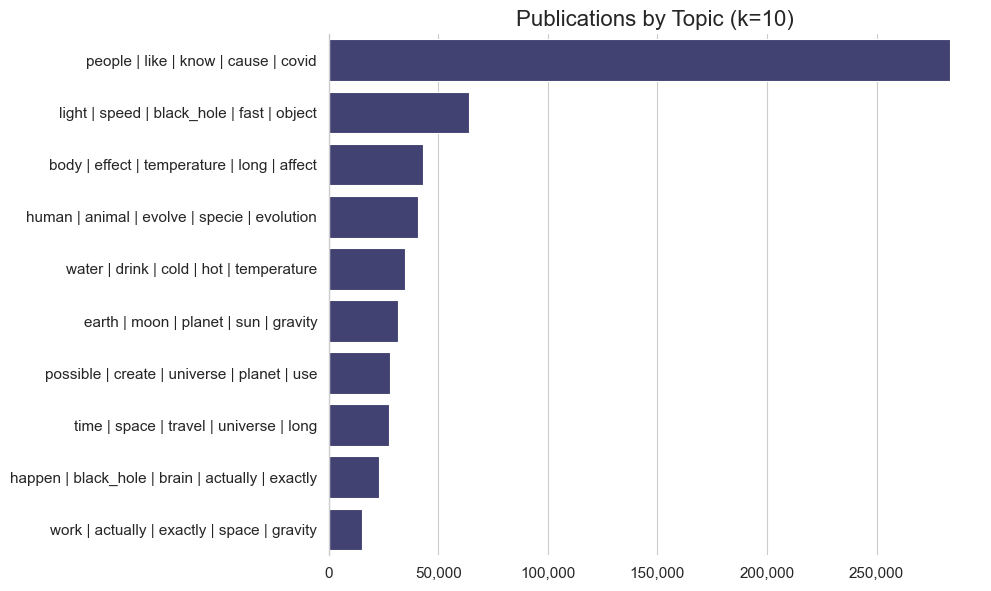

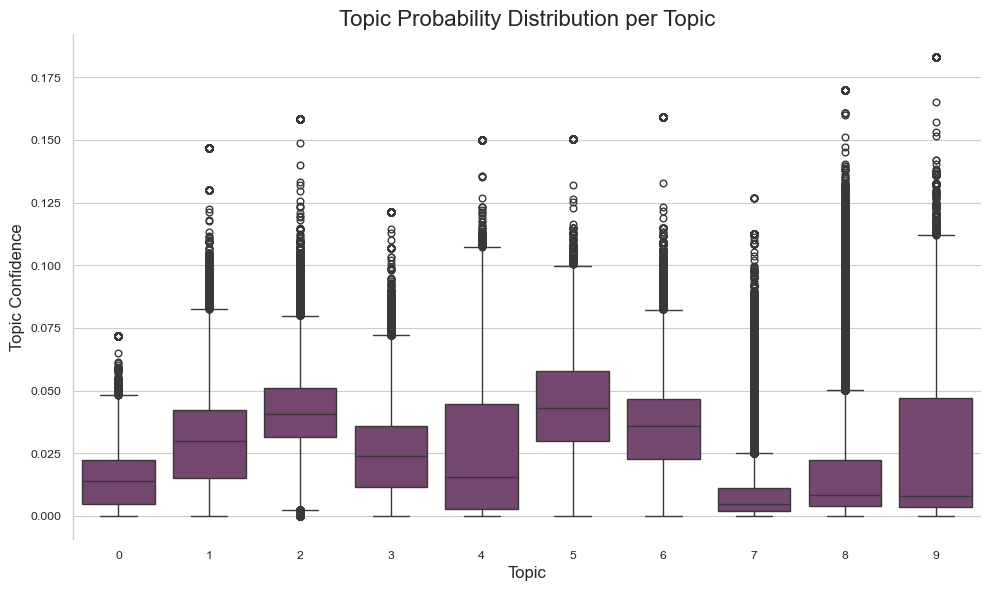

In [ ]:
# Plot topic distribution
plot_bars_topic_distribution(k=k)

# Plot topic confidence
plot_box_topic_confidence(k=k)

In [ ]:
k = 18
nmf = NMF(n_components=k, random_state=42, init='nndsvda', max_iter=1000)

W = nmf.fit_transform(X)

df["topic"] = W.argmax(axis=1)
df["topic_prob"] = W.max(axis=1)

topic_labels = get_topic_labels(nmf, vectorizer)
df["topic_label"] = df["topic"].map(topic_labels)

print(topic_labels)

# plot_2D_projection_nmf(nmf, X, k, df, vectorizer)

# Plot topic distribution
plot_bars_topic_distribution(k=k)

# Plot topic confidence
plot_box_topic_confidence(k=k)